<a href="https://colab.research.google.com/github/miamackk/Foundations-Of-Computer-Vision-Code/blob/main/18_Image_Derivatives.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
import numpy as np
from scipy.signal import convolve2d
from scipy.ndimage import uniform_filter1d, gaussian_filter, convolve1d
import cv2
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Chapter 18- Image Derivatives

all of the images for this notebook: https://drive.google.com/drive/folders/15K-1EqdtqdWgcGxHXPRiyWKlNAI_OAkd?usp=drive_link

In [ ]:
'''
Since using sobel filters changes image values, we will normalize color channels
before merging them back together
'''
def normalize(channel):
    mn, mx = channel.min(), channel.max()
    return ((channel - mn) / (mx - mn) * 255).astype(np.uint8)

In [ ]:
building = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 18/images/mit_der.png')
building = cv2.cvtColor(building, cv2.COLOR_BGR2RGB)

In [ ]:
r, g, b = cv2.split(building)


#x-derivative
sobel_x = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]])


r_conv = convolve2d(r, sobel_x, mode='valid')
g_conv = convolve2d(g, sobel_x, mode='valid')
b_conv = convolve2d(b, sobel_x, mode='valid')

sobel_x_img = cv2.merge((normalize(r_conv), normalize(g_conv), normalize(b_conv)))
#y-derivative
sobel_y = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])


r_conv = convolve2d(r, sobel_y, mode='valid')
g_conv = convolve2d(g, sobel_y, mode='valid')
b_conv = convolve2d(b, sobel_y, mode='valid')

sobel_y_img = cv2.merge((normalize(r_conv), normalize(g_conv), normalize(b_conv)))


(np.float64(-0.5), np.float64(125.5), np.float64(125.5), np.float64(-0.5))

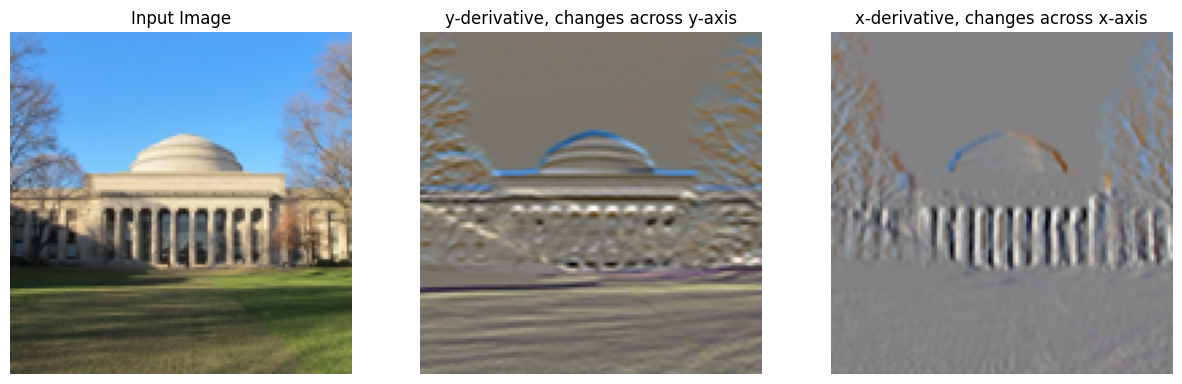

In [ ]:
# @title Figure 18.2
plt.figure(figsize=(15, 8))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(building)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("y-derivative, changes across y-axis")
plt.imshow(sobel_x_img)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("x-derivative, changes across x-axis")
plt.imshow(sobel_y_img)
plt.axis("off")

In [ ]:
stop_noise = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 18/images/stop_noise.png')
stop_noise = cv2.cvtColor(stop_noise, cv2.COLOR_BGR2RGB)

r, g, b = cv2.split(stop_noise)

In [ ]:
kernel = [1, -1]

#apply along x
r_der = convolve1d(r, weights=kernel, axis=0)
g_der = convolve1d(g, weights=kernel, axis=0)
b_der = convolve1d(b, weights=kernel, axis=0)

x_deriv = cv2.merge((r_der, g_der, b_der))


gaus_r_der = gaussian_filter(r, sigma=1, order=(1, 0))
gaus_g_der = gaussian_filter(g, sigma=1, order=(1, 0))
gaus_b_der = gaussian_filter(b, sigma=1, order=(1, 0))

x_deriv_gaus = cv2.merge((normalize(gaus_r_der), normalize(gaus_g_der), normalize(gaus_b_der)))




(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

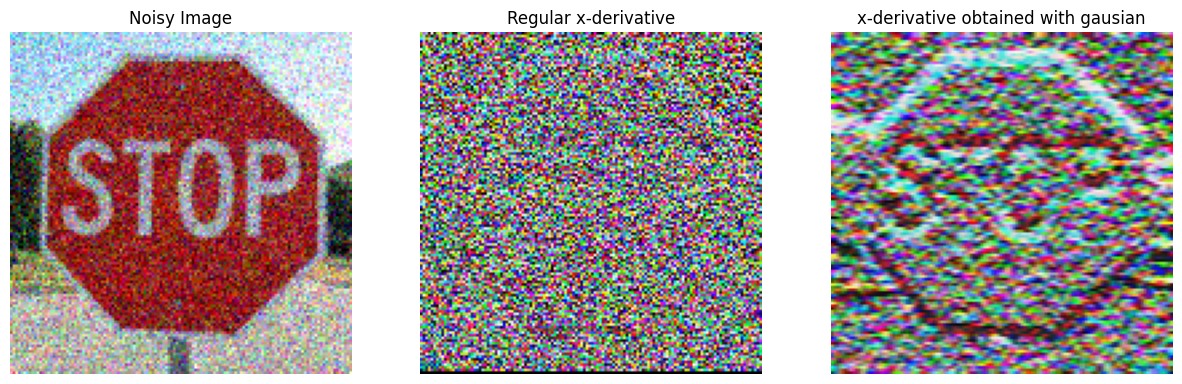

In [ ]:
# @title
plt.figure(figsize=(15, 8))

plt.subplot(1, 3, 1)
plt.imshow(stop_noise)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_deriv)
plt.title("Regular x-derivative")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(x_deriv_gaus)
plt.title("x-derivative obtained with gausian")
plt.axis("off")

In [ ]:
zebra = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 18/images/zebra.png', cv2.IMREAD_GRAYSCALE)

gaus_2 = gaussian_filter(zebra, sigma=2, order=(2, 0))

gaus_4 = gaussian_filter(zebra, sigma=4, order=(2, 0))

gaus_6 = gaussian_filter(zebra, sigma=6, order=(2, 0))

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

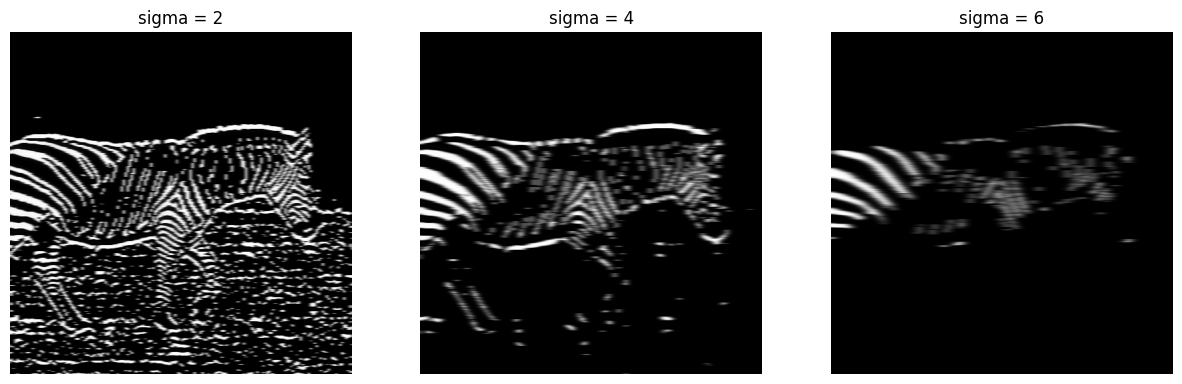

In [ ]:
# @title
plt.figure(figsize=(15, 8))
plt.set_cmap("gray")

plt.subplot(1, 3, 1)
plt.imshow(gaus_2)
plt.title("sigma = 2")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaus_4)
plt.title("sigma = 4")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gaus_6)
plt.title("sigma = 6")
plt.axis("off")

In [ ]:
circle_square = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 18/images/circle_square.png', cv2.IMREAD_GRAYSCALE)

#1st order deriv
gx= cv2.Sobel(circle_square, cv2.CV_64F, 1, 0, ksize=3)
gy= cv2.Sobel(circle_square, cv2.CV_64F, 0, 1, ksize=3)

# 2nd order deriv
gx2 = cv2.Sobel(gx, cv2.CV_64F, 1, 0, ksize=3)  # d^2g/dx^2
gxy = cv2.Sobel(gx, cv2.CV_64F, 0, 1, ksize=3)  # d^2g/dxdy
gy2 = cv2.Sobel(gy, cv2.CV_64F, 0, 1, ksize=3)  # d^2g/dy^2

# 3rd order deriv
gx3 = cv2.Sobel(gx2, cv2.CV_64F, 1, 0, ksize=3)
gx2y = cv2.Sobel(gx2, cv2.CV_64F, 0, 1, ksize=3)
gxy2 = cv2.Sobel(gxy, cv2.CV_64F, 0, 1, ksize=3)
gy3 = cv2.Sobel(gy2, cv2.CV_64F, 0, 1, ksize=3)

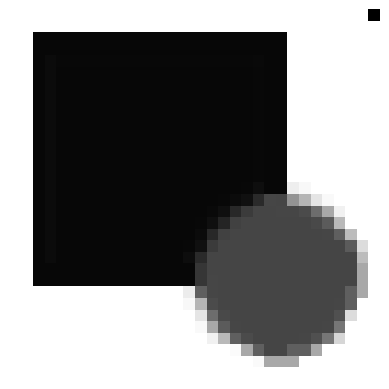

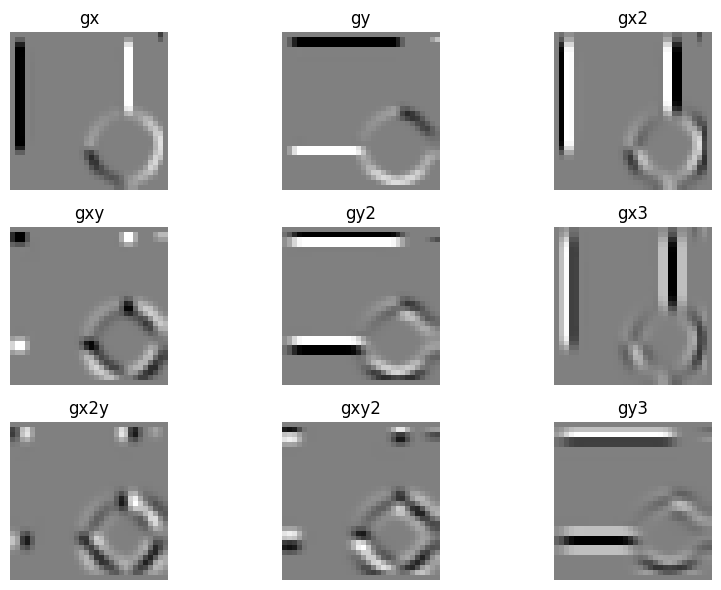

In [ ]:
# @title
plt.imshow(circle_square, cmap="gray")
plt.axis("off")

def show_derivative(ax, img, title):

    vmax = np.max(np.abs(img))
    ax.imshow(img, cmap='gray', vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')

fig, axes = plt.subplots(3, 3, figsize=(9,6))
derivs = [
    (gx, 'gx'), (gy, 'gy'), (gx2, 'gx2'), (gxy, 'gxy'),
    (gy2, 'gy2'), (gx3, 'gx3'), (gx2y, 'gx2y'), (gxy2, 'gxy2'), (gy3, 'gy3')
]
for ax, (d, name) in zip(axes.flat, derivs):
    show_derivative(ax, d, name)
plt.tight_layout()
plt.show()

In [ ]:
wheel = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 18/images/wheel256.jpg', cv2.IMREAD_GRAYSCALE)

#1st order (same as last)
gx= cv2.Sobel(wheel, cv2.CV_64F, 1, 0, ksize=3)
gy= cv2.Sobel(wheel, cv2.CV_64F, 0, 1, ksize=3)
# 2nd order
gx2 = cv2.Sobel(gx, cv2.CV_64F, 1, 0, ksize=3)
gy2 = cv2.Sobel(gy, cv2.CV_64F, 0, 1, ksize=3)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

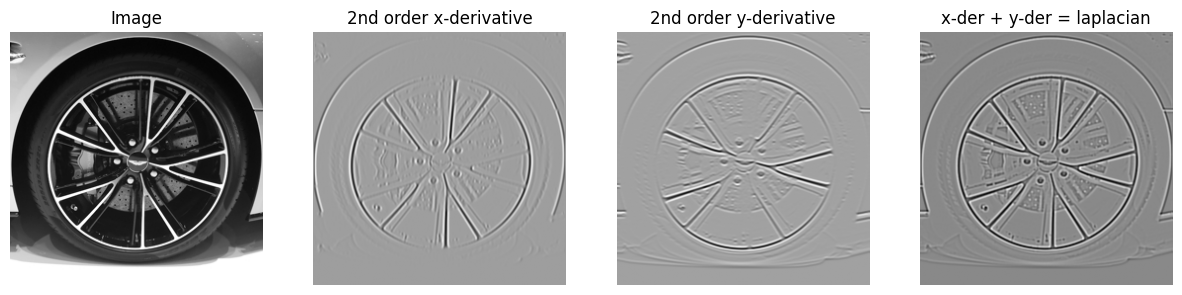

In [ ]:
# @title
plt.figure(figsize=(15, 6))

plt.subplot(1, 4, 1)
plt.imshow(wheel, cmap = "gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gx2)
plt.title("2nd order x-derivative")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(gy2)
plt.title("2nd order y-derivative")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(gx2 + gy2)
plt.title("x-der + y-der = laplacian")
plt.axis("off")

In [ ]:
sailboat = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 18/images/sailboat.png')
sailboat = cv2.cvtColor(sailboat, cv2.COLOR_BGR2RGB)

def sharpen(image):

  first = np.array([[0, 0, 0],
                    [0, 2, 0],
                    [0, 0, 0]])

  second = np.array([[1, 2, 1],
                    [2, 4, 2],
                    [1, 2, 1]])/16

  sharpen = first - second

  result = image.copy().astype(np.float64)
  r, g, b = cv2.split(result)

  r = convolve2d(r, sharpen, mode='same')
  g = convolve2d(g, sharpen, mode='same')
  b = convolve2d(b, sharpen, mode='same')

  result = cv2.merge((r, g, b))

  return np.clip(result, 0, 255).astype(np.uint8) #clip to valid range


sharp1 = sharpen(sailboat)
sharp2 = sharpen(sharp1)
sharp3 = sharpen(sharp2)
sharp4 = sharpen(sharp3)
sharp5 = sharpen(sharp4)

(np.float64(-0.5), np.float64(268.5), np.float64(268.5), np.float64(-0.5))

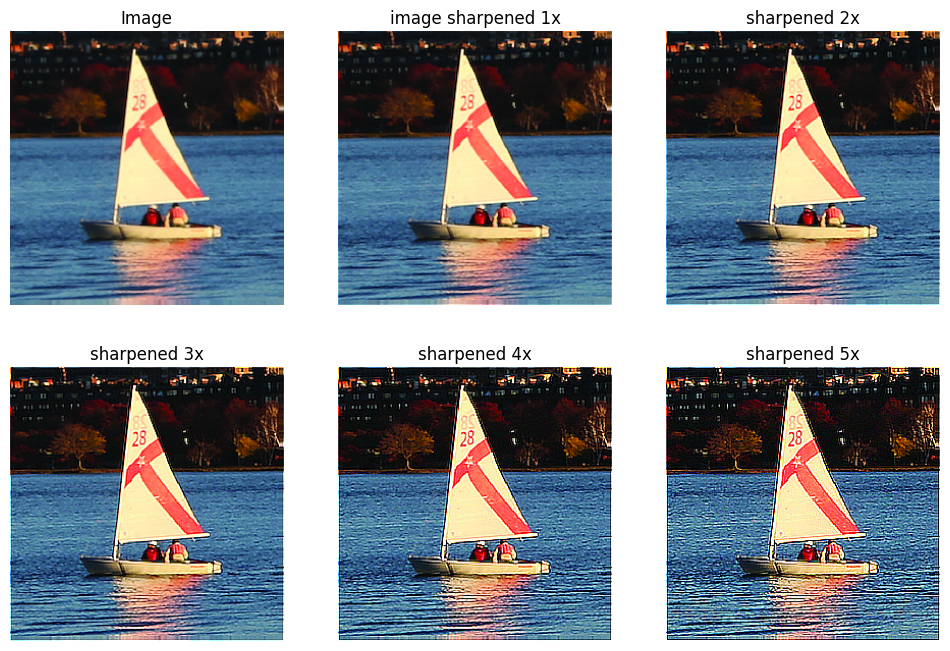

In [ ]:
# @title
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Image")
plt.imshow(sailboat)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(sharp1)
plt.title("image sharpened 1x")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(sharp2)
plt.title("sharpened 2x")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sharp3)
plt.title("sharpened 3x")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sharp4)
plt.title("sharpened 4x")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(sharp5)
plt.title("sharpened 5x")
plt.axis("off")